<a href="https://colab.research.google.com/github/GinoAlfaro/Ingenieria-del-conocimiento/blob/main/Sesion_02_ejercicio_3_ALFARO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio 3 — Aplicación con dataset propio
**Curso:** Ingeniería del Conocimiento (ISO56B)  
**Docente:** Msc. Jaime Antonio Huaytalla Pariona  
**Periodo:** 2026-II | Universidad Nacional del Centro del Perú  

**Dataset seleccionado:** Digits — reconocimiento de dígitos escritos a mano

---

## Objetivo
Implementar, comparar y analizar cuatro modelos fundamentales de clasificación supervisada — **Regresión Logística, Árbol de Decisión, SVM y KNN** — sobre el dataset **Digits**, evaluando su desempeño mediante **F1 Macro**, Accuracy y validación cruzada.

El dataset cumple con el requisito del ejercicio: contiene **1797 registros**, **64 features** y **10 clases**.


## 1. Configuración del entorno


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_digits
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score, f1_score,
    roc_curve, auc
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
print('Entorno configurado correctamente.')


Entorno configurado correctamente.


## 2. Carga y comprensión del dataset

**Dataset:** Digits — Optical Recognition of Handwritten Digits  
**Fuente:** UCI Machine Learning Repository  
**URL:** https://archive.ics.uci.edu/dataset/80/optical+recognition+of+handwritten+digits

El dataset contiene imágenes de dígitos escritos a mano representadas mediante una matriz de 8×8 píxeles. En esta implementación se utiliza la versión incluida en `scikit-learn`, que contiene 1797 registros y 64 características.


In [ ]:
# Carga del dataset Digits
digits = load_digits()

# Construcción del DataFrame
features = [f'pixel_{i}' for i in range(digits.data.shape[1])]
df = pd.DataFrame(digits.data, columns=features)
df['target'] = digits.target

print(f'Dataset cargado: {df.shape[0]} registros, {df.shape[1]} columnas')
print(f'Features predictoras: {len(features)}')
print(f'Número de clases: {df["target"].nunique()}')
print(f'Clases: {sorted(df["target"].unique())}')

df.head()


Dataset cargado: 1797 registros, 65 columnas
Features predictoras: 64
Número de clases: 10
Clases: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,pixel_10,pixel_11,pixel_12,pixel_13,pixel_14,pixel_15,pixel_16,pixel_17,pixel_18,pixel_19,pixel_20,pixel_21,pixel_22,pixel_23,pixel_24,pixel_25,pixel_26,pixel_27,pixel_28,pixel_29,pixel_30,pixel_31,pixel_32,pixel_33,pixel_34,pixel_35,pixel_36,pixel_37,pixel_38,pixel_39,pixel_40,pixel_41,pixel_42,pixel_43,pixel_44,pixel_45,pixel_46,pixel_47,pixel_48,pixel_49,pixel_50,pixel_51,pixel_52,pixel_53,pixel_54,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,13.0,15.0,10.0,15.0,5.0,0.0,0.0,3.0,15.0,2.0,0.0,11.0,8.0,0.0,0.0,4.0,12.0,0.0,0.0,8.0,8.0,0.0,0.0,5.0,8.0,0.0,0.0,9.0,8.0,0.0,0.0,4.0,11.0,0.0,1.0,12.0,7.0,0.0,0.0,2.0,14.0,5.0,10.0,12.0,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,9.0,0.0,0.0,0.0,0.0,3.0,15.0,16.0,6.0,0.0,0.0,0.0,7.0,15.0,16.0,16.0,2.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,3.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,3.0,16.0,15.0,14.0,0.0,0.0,0.0,0.0,8.0,13.0,8.0,16.0,0.0,0.0,0.0,0.0,1.0,6.0,15.0,11.0,0.0,0.0,0.0,1.0,8.0,13.0,15.0,1.0,0.0,0.0,0.0,9.0,16.0,16.0,5.0,0.0,0.0,0.0,0.0,3.0,13.0,16.0,16.0,11.0,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,13.0,6.0,15.0,4.0,0.0,0.0,0.0,2.0,1.0,13.0,13.0,0.0,0.0,0.0,0.0,0.0,2.0,15.0,11.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,12.0,12.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,10.0,8.0,0.0,0.0,0.0,8.0,4.0,5.0,14.0,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,8.0,0.0,0.0,0.0,0.0,0.0,1.0,13.0,6.0,2.0,2.0,0.0,0.0,0.0,7.0,15.0,0.0,9.0,8.0,0.0,0.0,5.0,16.0,10.0,0.0,16.0,6.0,0.0,0.0,4.0,15.0,16.0,13.0,16.0,1.0,0.0,0.0,0.0,0.0,3.0,15.0,10.0,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


Distribución de clases:
target
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


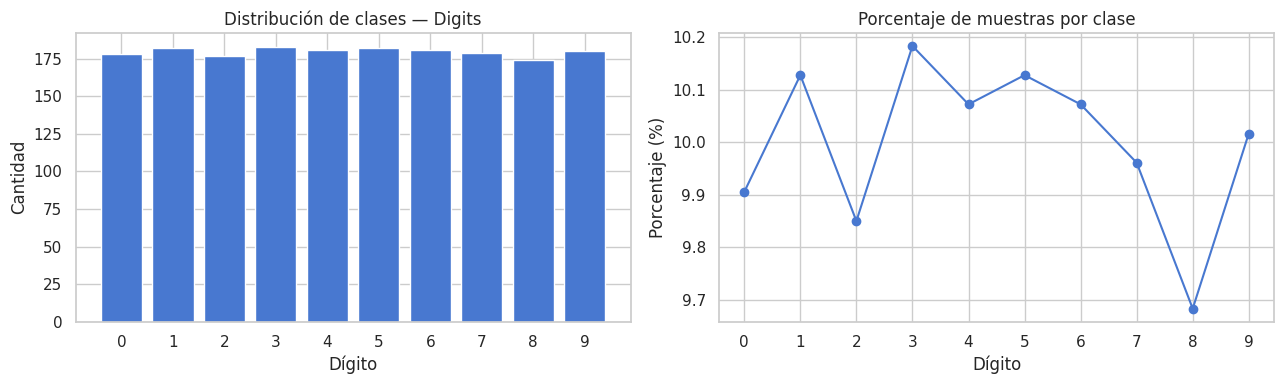


Clase con más muestras: 3 (183)
Clase con menos muestras: 8 (174)
Ratio mayor/menor: 1.05:1


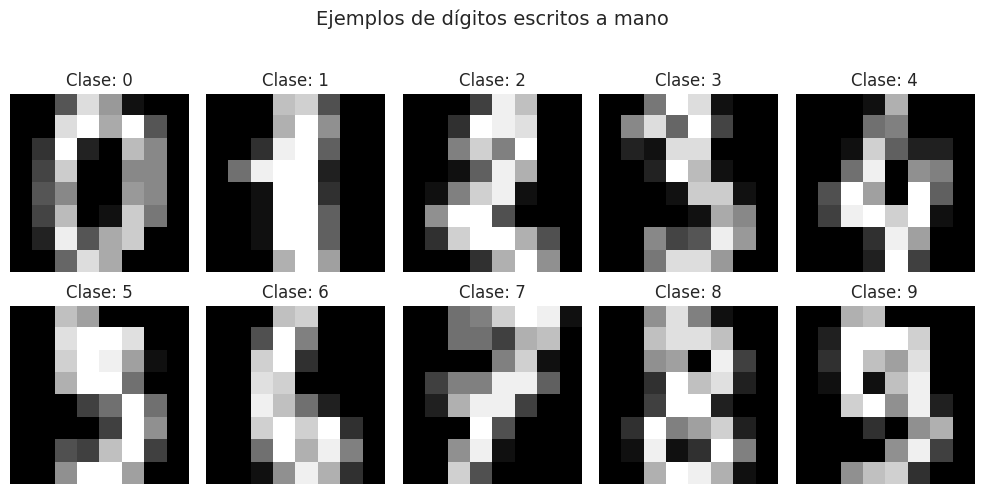

In [ ]:
# Distribución de la variable objetivo y ejemplos visuales
print('Distribución de clases:')
counts = df['target'].value_counts().sort_index()
print(counts)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(counts.index.astype(str), counts.values)
axes[0].set_title('Distribución de clases — Digits')
axes[0].set_xlabel('Dígito')
axes[0].set_ylabel('Cantidad')

percentages = counts / counts.sum() * 100
axes[1].plot(counts.index, percentages.values, marker='o')
axes[1].set_title('Porcentaje de muestras por clase')
axes[1].set_xlabel('Dígito')
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_xticks(counts.index)

plt.tight_layout()
plt.show()

print(f'\nClase con más muestras: {counts.idxmax()} ({counts.max()})')
print(f'Clase con menos muestras: {counts.idxmin()} ({counts.min()})')
print(f'Ratio mayor/menor: {counts.max()/counts.min():.2f}:1')

# Visualización de ejemplos
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'Clase: {digits.target[i]}')
    ax.axis('off')

fig.suptitle('Ejemplos de dígitos escritos a mano', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


---
## 3. Análisis exploratorio orientado a clasificación


Resumen por clase:


,Muestras,Intensidad media,Desviación media
target,,,
0,178,4.952,1.998
1,182,4.894,3.051
2,177,4.905,2.809
3,183,4.794,2.568
4,181,4.855,2.737
5,182,4.800,2.772
6,181,4.863,2.164
7,179,4.739,2.718
8,174,5.155,2.752


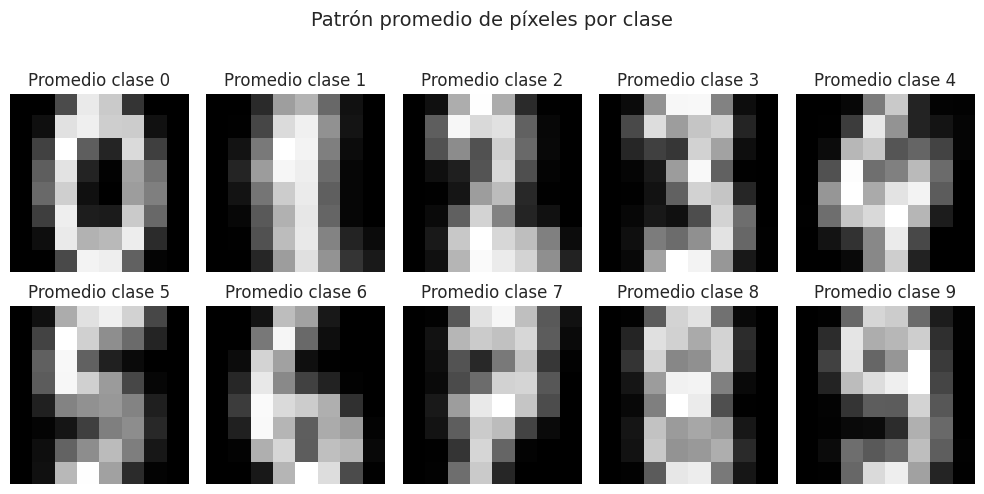

In [ ]:
# 3.1  Estadísticas descriptivas por clase
class_means = df.groupby('target')[features].mean()

summary_by_class = pd.DataFrame({
    'Muestras': df['target'].value_counts().sort_index(),
    'Intensidad media': class_means.mean(axis=1),
    'Desviación media': df.groupby('target')[features].std().mean(axis=1)
}).round(3)

print('Resumen por clase:')
display(summary_by_class)

# Imagen promedio de cada clase
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for digit, ax in enumerate(axes.flatten()):
    avg_image = class_means.loc[digit].values.reshape(8, 8)
    ax.imshow(avg_image, cmap='gray')
    ax.set_title(f'Promedio clase {digit}')
    ax.axis('off')

fig.suptitle('Patrón promedio de píxeles por clase', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


8 píxeles con mayor varianza:
['pixel_42', 'pixel_43', 'pixel_34', 'pixel_35', 'pixel_44', 'pixel_21', 'pixel_26', 'pixel_20']


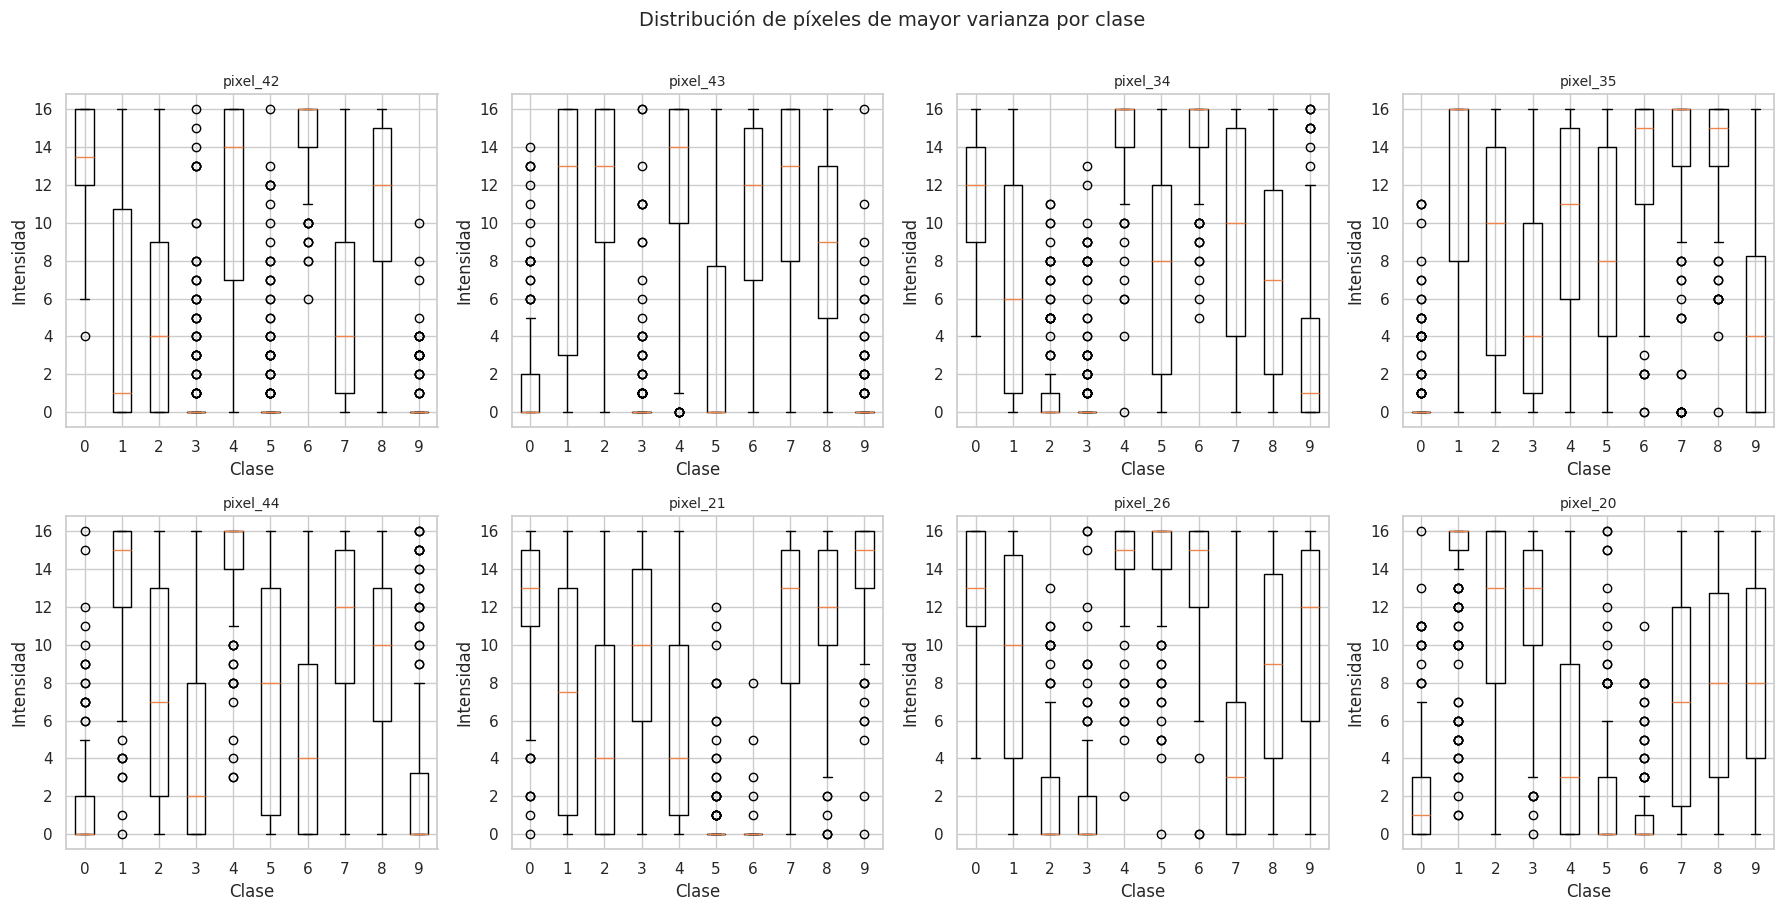

In [ ]:
# 3.2  Distribución de features por clase (píxeles de mayor varianza)
top_features = df[features].var().nlargest(8).index.tolist()

print('8 píxeles con mayor varianza:')
print(top_features)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(top_features):
    data_by_class = [
        df.loc[df['target'] == digit, col].values
        for digit in range(10)
    ]
    axes[i].boxplot(data_by_class, tick_labels=[str(d) for d in range(10)])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Clase')
    axes[i].set_ylabel('Intensidad')

fig.suptitle('Distribución de píxeles de mayor varianza por clase', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


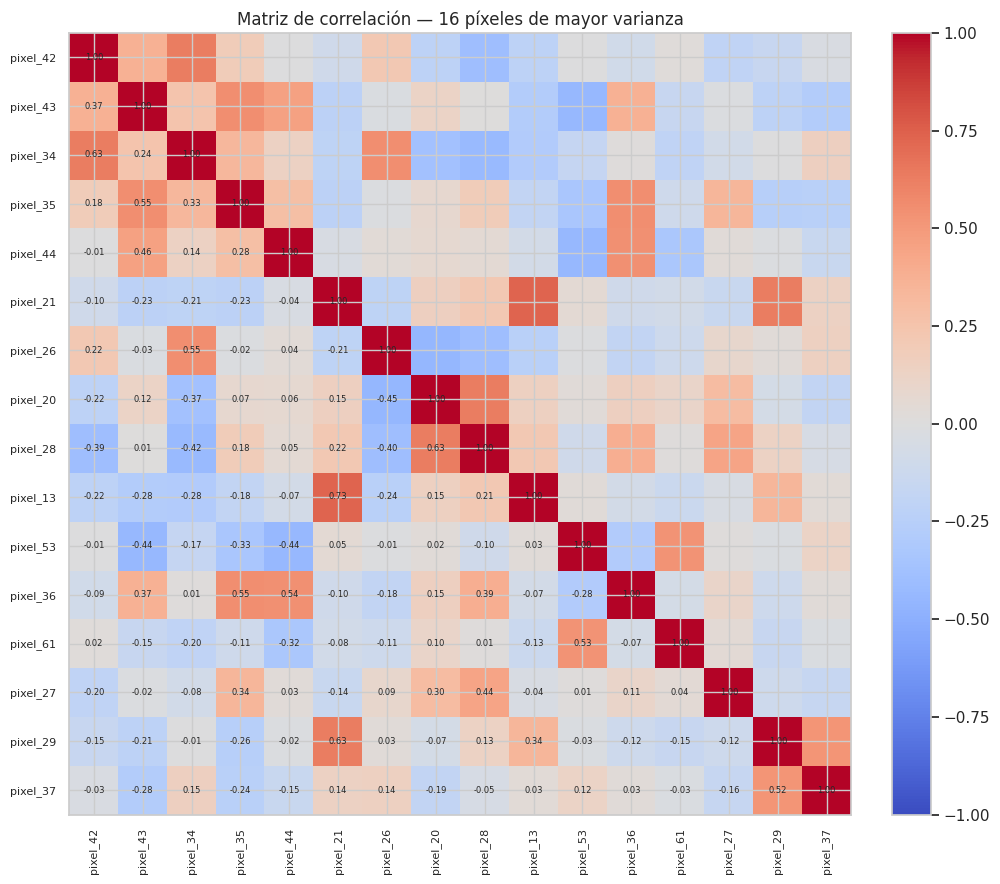

In [ ]:
# 3.3  Correlación entre features
# Se muestran 16 píxeles de mayor varianza para mantener la matriz legible.
corr_features = df[features].var().nlargest(16).index.tolist()
corr = df[corr_features].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap='coolwarm')

ax.set_xticks(range(len(corr_features)))
ax.set_yticks(range(len(corr_features)))
ax.set_xticklabels(corr_features, rotation=90, fontsize=8)
ax.set_yticklabels(corr_features, fontsize=8)

for i in range(len(corr_features)):
    for j in range(len(corr_features)):
        if i >= j:
            ax.text(j, i, f'{corr.iloc[i, j]:.2f}',
                    ha='center', va='center', fontsize=6)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Matriz de correlación — 16 píxeles de mayor varianza')
plt.tight_layout()
plt.show()


---
## 4. Preparación de datos


In [ ]:
# 4.1  Separación features / target
X = df[features].copy()
y = df['target'].copy()

# 4.2  Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras  |  Test: {X_test.shape[0]} muestras')

class_proportions = pd.DataFrame({
    'Train': y_train.value_counts(normalize=True).sort_index(),
    'Test': y_test.value_counts(normalize=True).sort_index()
}).round(3)

print('\nProporción de clases:')
display(class_proportions)


Train: 1437 muestras  |  Test: 360 muestras

Proporción de clases:


,Train,Test
target,,
0,0.099,0.100
1,0.102,0.100
2,0.099,0.097
3,0.102,0.103
4,0.101,0.100
5,0.101,0.103
6,0.101,0.100
7,0.100,0.100
8,0.097,0.097


In [ ]:
# 4.3  Verificación de escalas
scale_summary = pd.DataFrame({
    'mínimo': X_train.min(),
    'máximo': X_train.max(),
    'rango': X_train.max() - X_train.min(),
    'desv_std': X_train.std()
})

print('Resumen de escalas de las features:')
display(scale_summary.describe().round(3))

constant_features = scale_summary.index[scale_summary['desv_std'] == 0].tolist()

print(f'\nRango global de intensidades: [{X_train.min().min():.0f}, {X_train.max().max():.0f}]')
print(f'Features constantes en train: {len(constant_features)}')
print('\n→ Los píxeles comparten una escala común (0–16), pero presentan varianzas distintas.')
print('  Se utilizará StandardScaler en Regresión Logística, SVM y KNN')
print('  para mantener un tratamiento consistente de las features.')


Resumen de escalas de las features:


,mínimo,máximo,rango,desv_std
count,64.0,64.000,64.000,64.000
mean,0.0,13.000,13.000,3.679
std,0.0,5.437,5.437,2.300
min,0.0,0.000,0.000,0.000
25%,0.0,13.750,13.750,1.056
50%,0.0,16.000,16.000,4.243
75%,0.0,16.000,16.000,5.808
max,0.0,16.000,16.000,6.533



Rango global de intensidades: [0, 16]
Features constantes en train: 3

→ Los píxeles comparten una escala común (0–16), pero presentan varianzas distintas.
  Se utilizará StandardScaler en Regresión Logística, SVM y KNN
  para mantener un tratamiento consistente de las features.


---
## 5. Modelo 1 — Regresión Logística

**Fundamento:** Modelo lineal que estima la probabilidad de pertenencia a cada clase. En un problema multiclase como Digits funciona como un **baseline** rápido, interpretable y eficiente.


In [ ]:
# 5.1  Pipeline con estandarización
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

# Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores_lr = cross_val_score(
    pipe_lr, X_train, y_train,
    cv=cv, scoring='f1_macro', n_jobs=-1
)
print(f'Logistic Regression — F1 Macro CV: {scores_lr.mean():.4f} ± {scores_lr.std():.4f}')

# Entrenamiento final
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

print(f'Accuracy Test: {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'F1 Macro Test: {f1_score(y_test, y_pred_lr, average="macro"):.4f}')


Logistic Regression — F1 Macro CV: 0.9679 ± 0.0073
Accuracy Test: 0.9722
F1 Macro Test: 0.9719


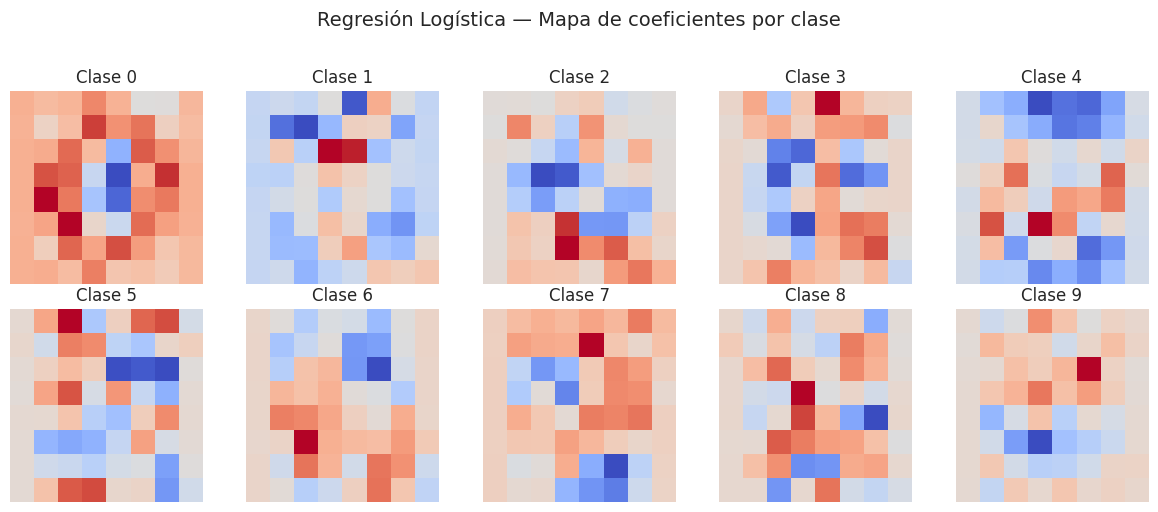

Interpretación: coeficientes de mayor magnitud indican píxeles con mayor
influencia en la decisión del modelo para cada dígito.


In [ ]:
# 5.2  Coeficientes del modelo (interpretabilidad multiclase)
coefs_lr = pipe_lr.named_steps['clf'].coef_

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit, ax in enumerate(axes.flatten()):
    coef_image = coefs_lr[digit].reshape(8, 8)
    ax.imshow(coef_image, cmap='coolwarm')
    ax.set_title(f'Clase {digit}')
    ax.axis('off')

fig.suptitle('Regresión Logística — Mapa de coeficientes por clase', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Interpretación: coeficientes de mayor magnitud indican píxeles con mayor')
print('influencia en la decisión del modelo para cada dígito.')


---
## 6. Modelo 2 — Árbol de Decisión

**Fundamento:** Modelo no lineal que divide el espacio de features mediante reglas jerárquicas. Es interpretable y no necesita estandarización, pero puede sobreajustar si su profundidad crece demasiado.


In [ ]:
# 6.1  Selección de profundidad y entrenamiento
depths = range(1, 21)
train_scores_dt = []
val_scores_dt = []

for d in depths:
    dt_temp = DecisionTreeClassifier(
        max_depth=d,
        min_samples_leaf=10,
        random_state=RANDOM_STATE
    )

    dt_temp.fit(X_train, y_train)

    train_scores_dt.append(
        f1_score(
            y_train,
            dt_temp.predict(X_train),
            average='macro'
        )
    )

    cv_s = cross_val_score(
        dt_temp, X_train, y_train,
        cv=cv, scoring='f1_macro', n_jobs=-1
    )

    val_scores_dt.append(cv_s.mean())

best_depth = list(depths)[int(np.argmax(val_scores_dt))]

pipe_dt = Pipeline([
    ('clf', DecisionTreeClassifier(
        max_depth=best_depth,
        min_samples_leaf=10,
        random_state=RANDOM_STATE
    ))
])

scores_dt = cross_val_score(
    pipe_dt, X_train, y_train,
    cv=cv, scoring='f1_macro', n_jobs=-1
)

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

print(f'Mejor profundidad: {best_depth}')
print(f'Decision Tree — F1 Macro CV: {scores_dt.mean():.4f} ± {scores_dt.std():.4f}')
print(f'Accuracy Test: {accuracy_score(y_test, y_pred_dt):.4f}')
print(f'F1 Macro Test: {f1_score(y_test, y_pred_dt, average="macro"):.4f}')


Mejor profundidad: 10
Decision Tree — F1 Macro CV: 0.8141 ± 0.0153
Accuracy Test: 0.7889
F1 Macro Test: 0.7902


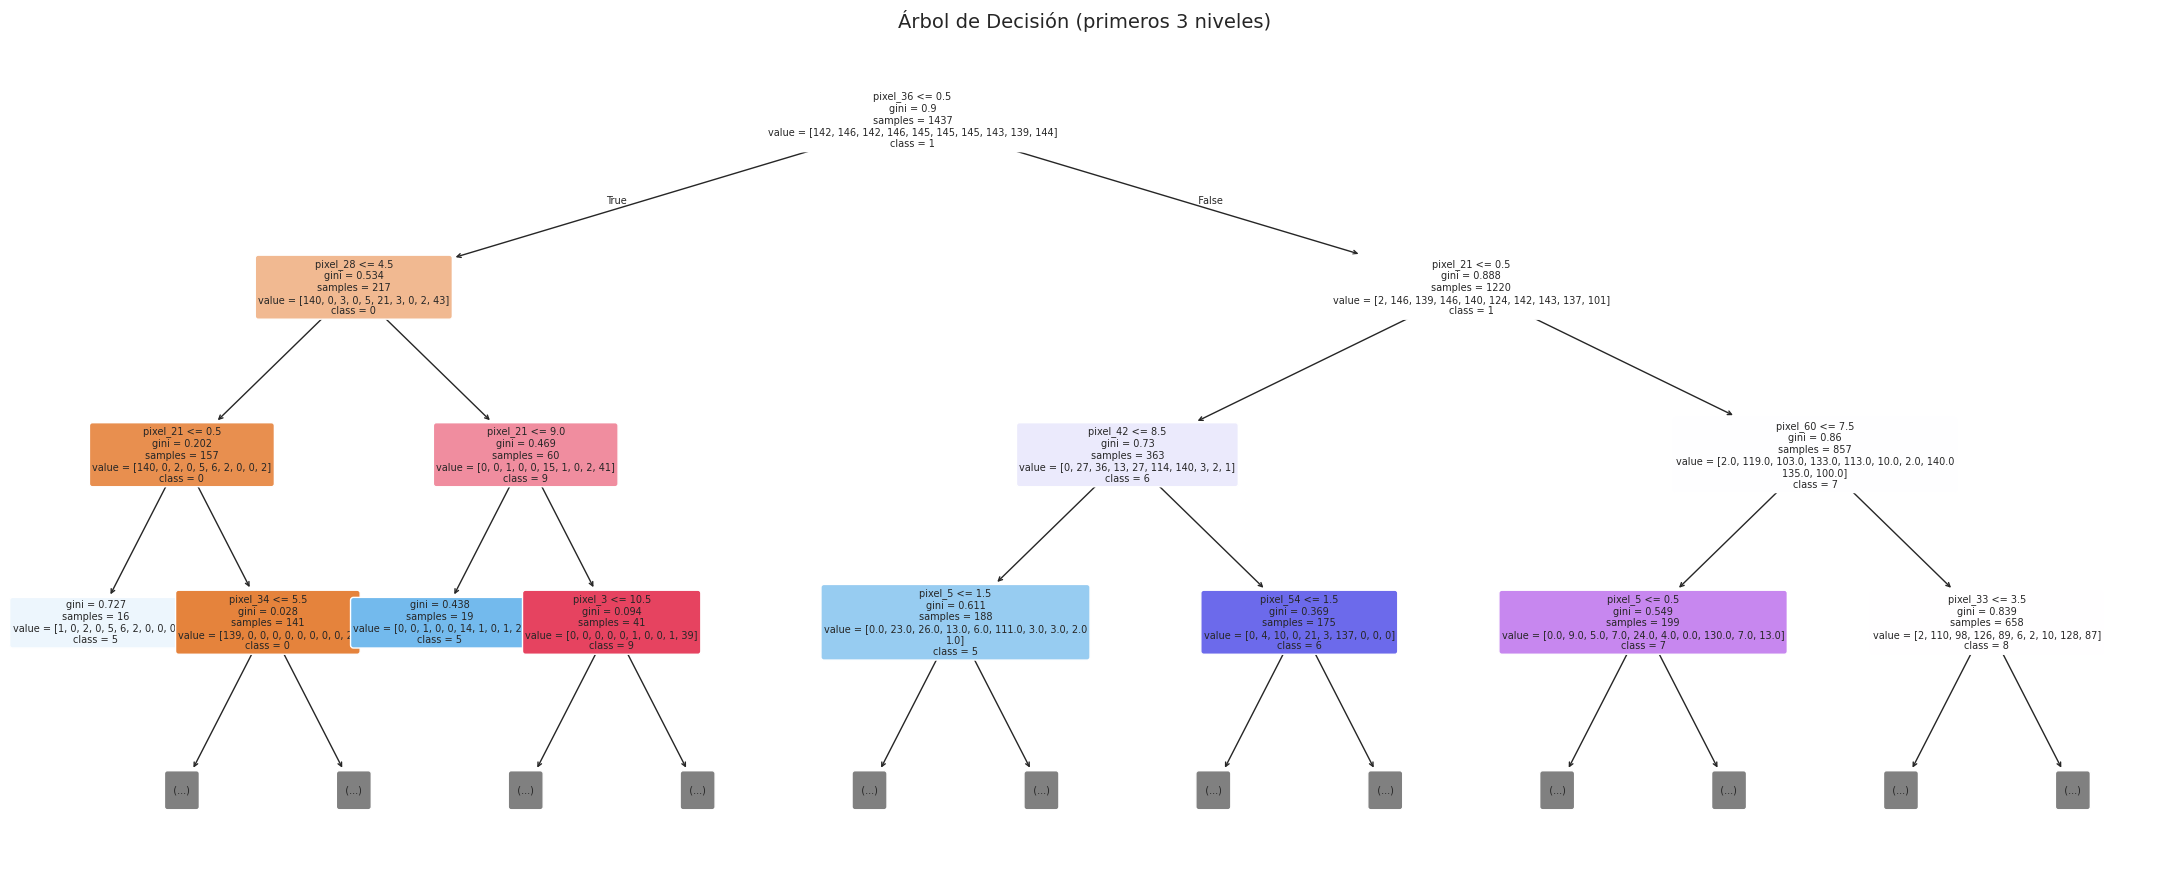

In [ ]:
# 6.2  Visualización del árbol
fig, ax = plt.subplots(figsize=(22, 9))

plot_tree(
    pipe_dt.named_steps['clf'],
    feature_names=list(features),
    class_names=[str(i) for i in digits.target_names],
    filled=True,
    rounded=True,
    fontsize=7,
    ax=ax,
    max_depth=3
)

ax.set_title('Árbol de Decisión (primeros 3 niveles)', fontsize=14)
plt.tight_layout()
plt.show()


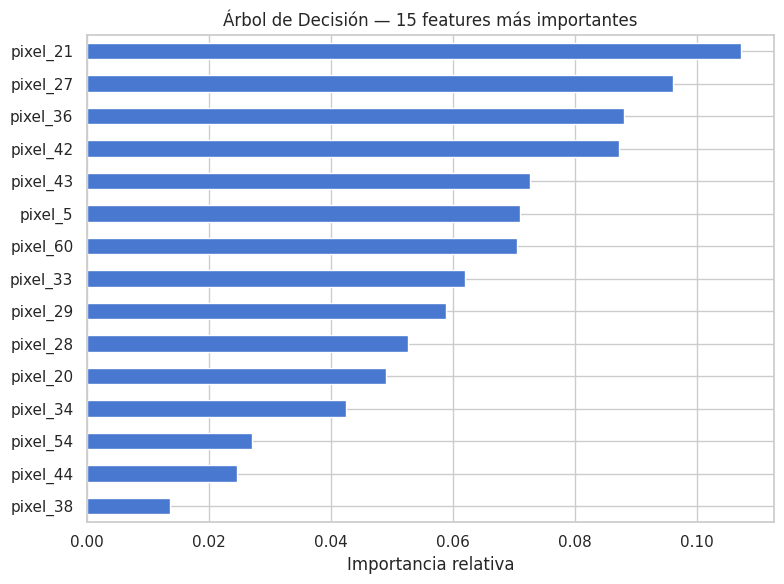

Features más importantes:


,Importancia
pixel_21,0.1073
pixel_27,0.0961
pixel_36,0.0881
pixel_42,0.0873
pixel_43,0.0727
pixel_5,0.0710
pixel_60,0.0705
pixel_33,0.0620
pixel_29,0.0590
pixel_28,0.0526


In [ ]:
# 6.3  Importancia de features (Gini importance)
importances = pd.Series(
    pipe_dt.named_steps['clf'].feature_importances_,
    index=features
).sort_values(ascending=False)

top_importances = importances.head(15).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
top_importances.plot(kind='barh', ax=ax)
ax.set_title('Árbol de Decisión — 15 features más importantes')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

print('Features más importantes:')
display(importances.head(10).to_frame('Importancia').round(4))


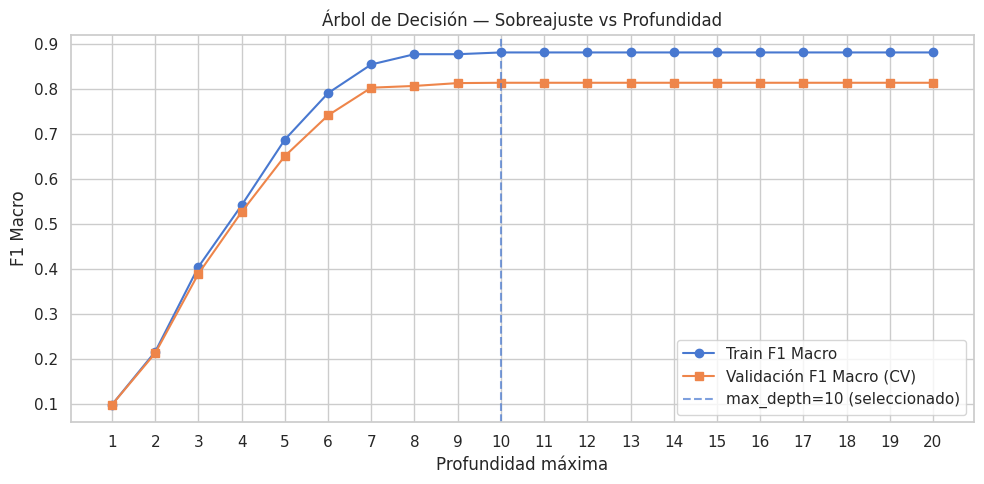

Profundidad seleccionada: 10
Mejor F1 Macro CV observado: 0.8141

Observación: una brecha grande entre train y validación indica sobreajuste.


In [ ]:
# 6.4  Efecto de la profundidad en sobreajuste/subajuste
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    list(depths),
    train_scores_dt,
    'o-',
    label='Train F1 Macro'
)

ax.plot(
    list(depths),
    val_scores_dt,
    's-',
    label='Validación F1 Macro (CV)'
)

ax.axvline(
    x=best_depth,
    linestyle='--',
    alpha=0.7,
    label=f'max_depth={best_depth} (seleccionado)'
)

ax.set_xlabel('Profundidad máxima')
ax.set_ylabel('F1 Macro')
ax.set_title('Árbol de Decisión — Sobreajuste vs Profundidad')
ax.legend()
ax.set_xticks(list(depths))

plt.tight_layout()
plt.show()

print(f'Profundidad seleccionada: {best_depth}')
print(f'Mejor F1 Macro CV observado: {max(val_scores_dt):.4f}')
print('\nObservación: una brecha grande entre train y validación indica sobreajuste.')


---
## 7. Modelo 3 — Support Vector Machine (SVM)

**Fundamento:** Busca fronteras de separación con el mayor margen posible. Mediante funciones **kernel** puede modelar relaciones no lineales y suele rendir bien en espacios de alta dimensionalidad.


In [ ]:
# 7.1  Comparación de kernels
kernels = ['linear', 'rbf', 'poly']
svm_results = {}

for kernel in kernels:
    pipe_svm_temp = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(
            kernel=kernel,
            random_state=RANDOM_STATE,
            probability=True
        ))
    ])

    scores = cross_val_score(
        pipe_svm_temp, X_train, y_train,
        cv=cv, scoring='f1_macro', n_jobs=-1
    )

    svm_results[kernel] = scores

    print(
        f'SVM ({kernel:6s}) — '
        f'F1 Macro CV: {scores.mean():.4f} ± {scores.std():.4f}'
    )

# Seleccionar el mejor kernel
best_kernel = max(
    svm_results,
    key=lambda k: svm_results[k].mean()
)

print(f'\nMejor kernel: {best_kernel}')


SVM (linear) — F1 Macro CV: 0.9769 ± 0.0072


SVM (rbf   ) — F1 Macro CV: 0.9812 ± 0.0059


SVM (poly  ) — F1 Macro CV: 0.9509 ± 0.0168

Mejor kernel: rbf


In [ ]:
# 7.2  Entrenamiento con el mejor kernel
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(
        kernel=best_kernel,
        random_state=RANDOM_STATE,
        probability=True
    ))
])

pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)
scores_svm = svm_results[best_kernel]

print(f'SVM ({best_kernel}) — F1 Macro CV: {scores_svm.mean():.4f} ± {scores_svm.std():.4f}')
print(f'Accuracy Test: {accuracy_score(y_test, y_pred_svm):.4f}')
print(f'F1 Macro Test: {f1_score(y_test, y_pred_svm, average="macro"):.4f}')


SVM (rbf) — F1 Macro CV: 0.9812 ± 0.0059
Accuracy Test: 0.9750
F1 Macro Test: 0.9748


In [ ]:
# 7.3  Impacto de la estandarización en SVM
svm_no_scale = SVC(
    kernel=best_kernel,
    random_state=RANDOM_STATE
)

scores_no_scale = cross_val_score(
    svm_no_scale, X_train, y_train,
    cv=cv, scoring='f1_macro', n_jobs=-1
)

difference_scale = (scores_svm.mean() - scores_no_scale.mean()) * 100

print('Impacto de la estandarización en SVM:')
print(f'  CON StandardScaler: F1 Macro = {scores_svm.mean():.4f}')
print(f'  SIN StandardScaler: F1 Macro = {scores_no_scale.mean():.4f}')
print(f'  Diferencia: {difference_scale:+.2f} puntos porcentuales')

if difference_scale > 1.0:
    print('\n→ En este dataset la estandarización mejora claramente el rendimiento.')
elif difference_scale < -1.0:
    print('\n→ En este dataset el SVM rinde claramente mejor sin estandarizar.')
    print('  Esto es coherente con que todos los píxeles ya comparten la escala 0–16.')
else:
    print('\n→ El efecto de la estandarización es pequeño en este dataset.')
    print('  Sin escalar resulta ligeramente superior; se mantiene StandardScaler')
    print('  para conservar el mismo esquema de preprocesamiento de la sesión.')


Impacto de la estandarización en SVM:
  CON StandardScaler: F1 Macro = 0.9812
  SIN StandardScaler: F1 Macro = 0.9881
  Diferencia: -0.69 puntos porcentuales

→ El efecto de la estandarización es pequeño en este dataset.
  Sin escalar resulta ligeramente superior; se mantiene StandardScaler
  para conservar el mismo esquema de preprocesamiento de la sesión.


---
## 8. Modelo 4 — K-Nearest Neighbors (KNN)

**Fundamento:** Clasifica cada muestra según las clases de sus vecinos más cercanos. Es un método no paramétrico, sensible a la representación de las features y al valor de **K**.


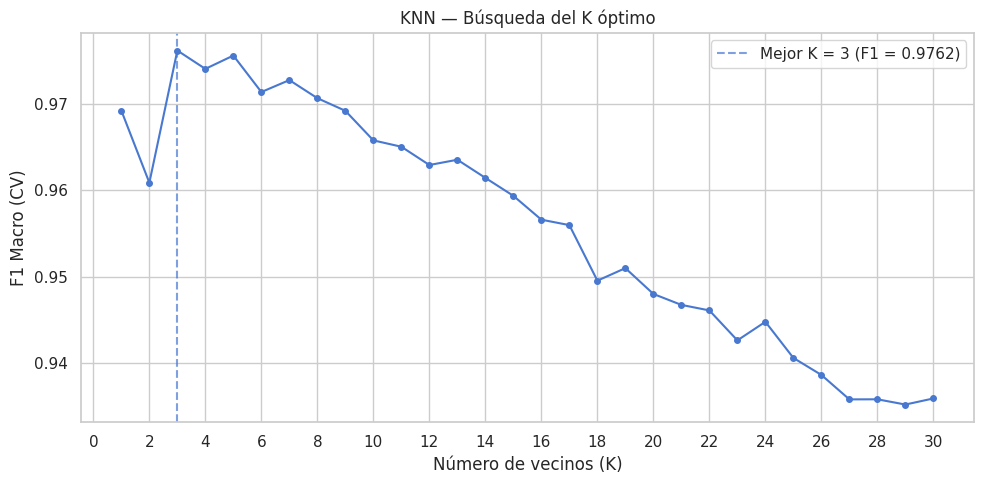

K óptimo: 3


In [ ]:
# 8.1  Búsqueda del K óptimo
k_range = range(1, 31)
k_scores = []

for k in k_range:
    pipe_knn_temp = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])

    scores = cross_val_score(
        pipe_knn_temp, X_train, y_train,
        cv=cv, scoring='f1_macro', n_jobs=-1
    )

    k_scores.append(scores.mean())

best_k = list(k_range)[int(np.argmax(k_scores))]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(k_range), k_scores, 'o-', markersize=4)
ax.axvline(
    x=best_k,
    linestyle='--',
    alpha=0.7,
    label=f'Mejor K = {best_k} (F1 = {max(k_scores):.4f})'
)
ax.set_xlabel('Número de vecinos (K)')
ax.set_ylabel('F1 Macro (CV)')
ax.set_title('KNN — Búsqueda del K óptimo')
ax.legend()
ax.set_xticks(range(0, 31, 2))
plt.tight_layout()
plt.show()

print(f'K óptimo: {best_k}')


In [ ]:
# 8.2  Entrenamiento con K óptimo
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=best_k))
])

scores_knn = cross_val_score(
    pipe_knn, X_train, y_train,
    cv=cv, scoring='f1_macro', n_jobs=-1
)

print(f'KNN (K={best_k}) — F1 Macro CV: {scores_knn.mean():.4f} ± {scores_knn.std():.4f}')

pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)

print(f'Accuracy Test: {accuracy_score(y_test, y_pred_knn):.4f}')
print(f'F1 Macro Test: {f1_score(y_test, y_pred_knn, average="macro"):.4f}')


KNN (K=3) — F1 Macro CV: 0.9762 ± 0.0076
Accuracy Test: 0.9667
F1 Macro Test: 0.9663


---
## 9. Análisis comparativo de modelos


In [ ]:
# 9.1  Tabla resumen
models = {
    'Logistic Regression': (pipe_lr, y_pred_lr, scores_lr),
    'Decision Tree':       (pipe_dt, y_pred_dt, scores_dt),
    f'SVM ({best_kernel})': (pipe_svm, y_pred_svm, scores_svm),
    f'KNN (K={best_k})':   (pipe_knn, y_pred_knn, scores_knn)
}

summary = []

for name, (pipe, y_pred, cv_scores) in models.items():
    summary.append({
        'Modelo': name,
        'F1 Macro CV (mean)': cv_scores.mean(),
        'F1 Macro CV (std)': cv_scores.std(),
        'Accuracy Test': accuracy_score(y_test, y_pred),
        'F1 Macro Test': f1_score(y_test, y_pred, average='macro')
    })

summary_df = pd.DataFrame(summary)
numeric_cols = summary_df.columns.drop('Modelo')
summary_df[numeric_cols] = summary_df[numeric_cols].round(4)

print('='*86)
print('COMPARACIÓN DE MODELOS — DATASET DIGITS')
print('='*86)

summary_df


COMPARACIÓN DE MODELOS — DATASET DIGITS


,Modelo,F1 Macro CV (mean),F1 Macro CV (std),Accuracy Test,F1 Macro Test
0,Logistic Regression,0.9679,0.0073,0.9722,0.9719
1,Decision Tree,0.8141,0.0153,0.7889,0.7902
2,SVM (rbf),0.9812,0.0059,0.9750,0.9748
3,KNN (K=3),0.9762,0.0076,0.9667,0.9663


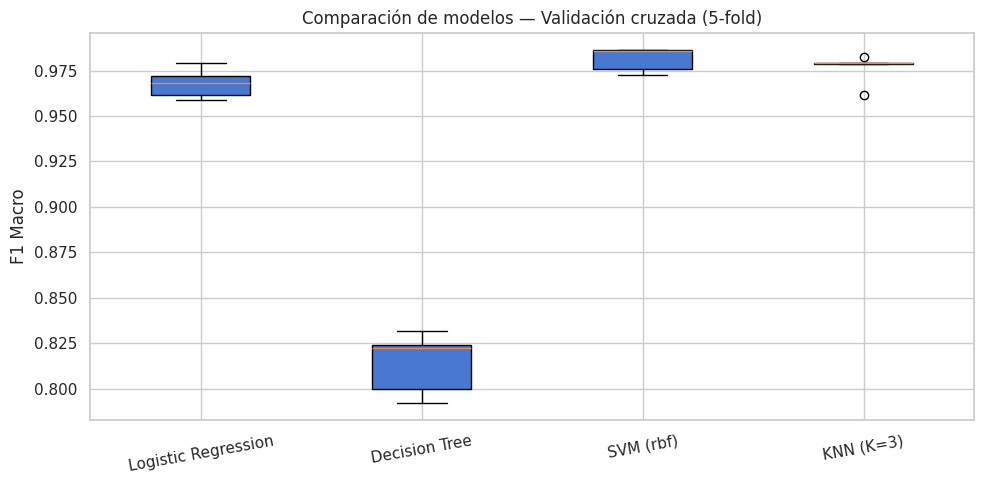

In [ ]:
# 9.2  Boxplot comparativo de validación cruzada
fig, ax = plt.subplots(figsize=(10, 5))

cv_data = [scores_lr, scores_dt, scores_svm, scores_knn]
labels = list(models.keys())

ax.boxplot(cv_data, tick_labels=labels, patch_artist=True)
ax.set_ylabel('F1 Macro')
ax.set_title('Comparación de modelos — Validación cruzada (5-fold)')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


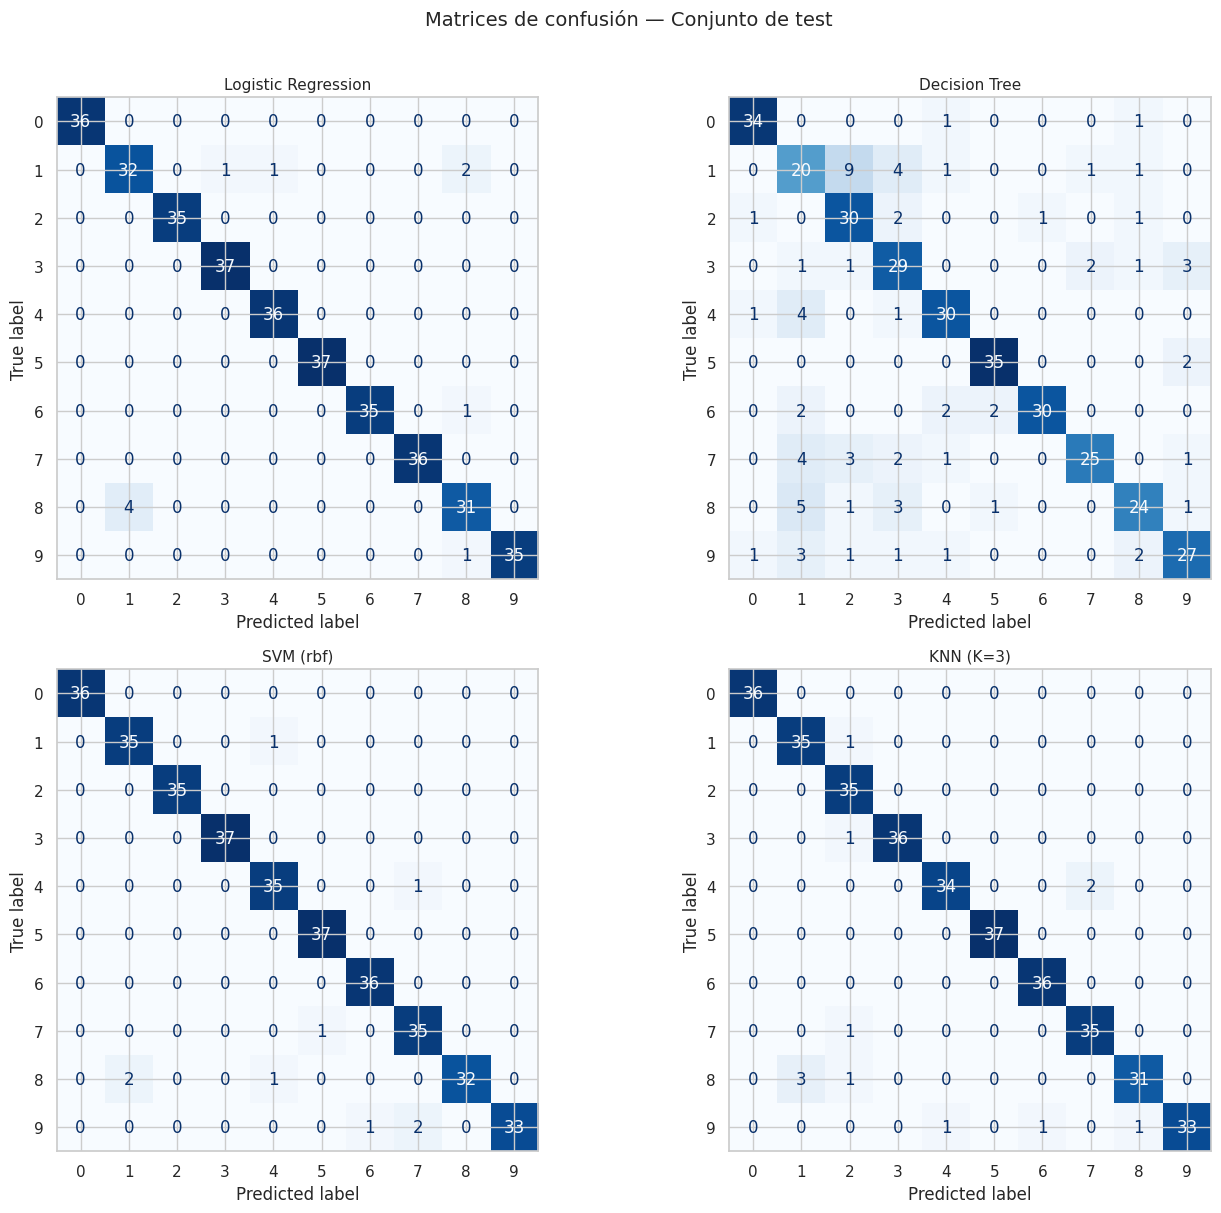

In [ ]:
# 9.3  Matrices de confusión comparativas
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (name, (pipe, y_pred, _)) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=np.arange(10),
        cmap='Blues',
        ax=ax,
        colorbar=False
    )
    ax.set_title(name, fontsize=11)

fig.suptitle(
    'Matrices de confusión — Conjunto de test',
    fontsize=14,
    y=1.01
)

plt.tight_layout()
plt.show()


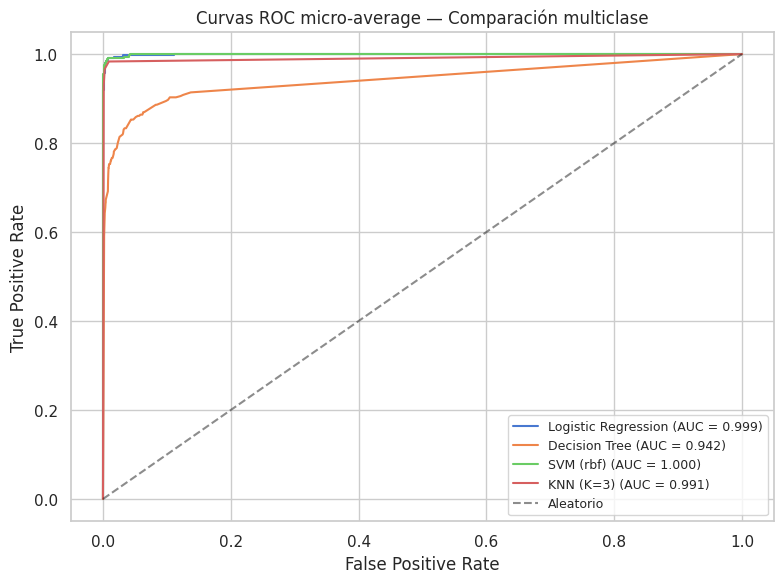

In [ ]:
# 9.4  Curvas ROC multiclase (micro-average)
# Se binarizan las 10 clases para calcular una curva global por modelo.
classes = np.arange(10)
y_test_bin = label_binarize(y_test, classes=classes)

fig, ax = plt.subplots(figsize=(8, 6))

for name, (pipe, _, _) in models.items():
    y_score = pipe.predict_proba(X_test)

    fpr, tpr, _ = roc_curve(
        y_test_bin.ravel(),
        y_score.ravel()
    )

    roc_auc = auc(fpr, tpr)

    ax.plot(
        fpr,
        tpr,
        label=f'{name} (AUC = {roc_auc:.3f})'
    )

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curvas ROC micro-average — Comparación multiclase')
ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
# 9.5  Classification report detallado del mejor modelo
best_model_name = max(
    models,
    key=lambda k: models[k][2].mean()
)

best_pipe, best_pred, best_cv = models[best_model_name]

print(f'Mejor modelo según F1 Macro CV: {best_model_name}')
print('='*70)

print(
    classification_report(
        y_test,
        best_pred,
        target_names=[f'Dígito {i}' for i in range(10)],
        zero_division=0
    )
)

report_best = classification_report(
    y_test,
    best_pred,
    output_dict=True,
    zero_division=0
)

class_f1 = {
    int(k): v['f1-score']
    for k, v in report_best.items()
    if k.isdigit()
}

hardest_class = min(class_f1, key=class_f1.get)

print(
    f'Clase con menor F1-score: {hardest_class} '
    f'(F1 = {class_f1[hardest_class]:.4f})'
)


Mejor modelo según F1 Macro CV: SVM (rbf)
              precision    recall  f1-score   support

    Dígito 0       1.00      1.00      1.00        36
    Dígito 1       0.95      0.97      0.96        36
    Dígito 2       1.00      1.00      1.00        35
    Dígito 3       1.00      1.00      1.00        37
    Dígito 4       0.95      0.97      0.96        36
    Dígito 5       0.97      1.00      0.99        37
    Dígito 6       0.97      1.00      0.99        36
    Dígito 7       0.92      0.97      0.95        36
    Dígito 8       1.00      0.91      0.96        35
    Dígito 9       1.00      0.92      0.96        36

    accuracy                           0.97       360
   macro avg       0.98      0.97      0.97       360
weighted avg       0.98      0.97      0.97       360

Clase con menor F1-score: 7 (F1 = 0.9459)


---
## 10. Resumen comparativo

| Modelo | Fortalezas | Limitaciones | ¿Cuándo usarlo? |
|---|---|---|---|
| **Regresión Logística** | Rápida, interpretable, buen baseline multiclase | Fronteras esencialmente lineales | Cuando se busca rapidez e interpretabilidad |
| **Árbol de Decisión** | Reglas explicables, maneja no linealidades, no requiere escalado | Puede sobreajustar o perder precisión con profundidad limitada | Cuando se necesitan decisiones interpretables |
| **SVM** | Buen desempeño en alta dimensionalidad; kernels flexibles | Menos interpretable; puede ser costoso en datasets grandes | Datasets medianos con fronteras complejas |
| **KNN** | Simple, no paramétrico y competitivo en datos estructurados | Predicción más costosa y sensible a K | Datasets pequeños o medianos con patrones locales |


In [ ]:
# 10.1  Hallazgos principales del experimento
best_index = summary_df['F1 Macro CV (mean)'].astype(float).idxmax()
best_row = summary_df.loc[best_index]

report_best = classification_report(
    y_test,
    best_pred,
    output_dict=True,
    zero_division=0
)

class_f1 = {
    int(k): v['f1-score']
    for k, v in report_best.items()
    if k.isdigit()
}

hardest_class = min(class_f1, key=class_f1.get)

print('HALLAZGOS PRINCIPALES')

print(f'Dataset: Digits ({len(df)} registros, {len(features)} features, 10 clases)')
print(f'Mejor modelo por validación cruzada: {best_model_name}')
print(f'F1 Macro CV: {best_cv.mean():.4f} ± {best_cv.std():.4f}')
print(f'Accuracy Test: {accuracy_score(y_test, best_pred):.4f}')
print(f'F1 Macro Test: {f1_score(y_test, best_pred, average="macro"):.4f}')
print(f'Clase más difícil para el mejor modelo: {hardest_class} '
      f'(F1 = {class_f1[hardest_class]:.4f})')


HALLAZGOS PRINCIPALES
Dataset: Digits (1797 registros, 64 features, 10 clases)
Mejor modelo por validación cruzada: SVM (rbf)
F1 Macro CV: 0.9812 ± 0.0059
Accuracy Test: 0.9750
F1 Macro Test: 0.9748
Clase más difícil para el mejor modelo: 7 (F1 = 0.9459)


---
Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II  
Ejercicio 3 — Aplicación con dataset propio
